In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Starting...")
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

Starting...


In [33]:
#Loaad dataset
df = pd.read_excel("Online Retail.xlsx")
print("Starting...")
print("Original records:", len(df))
#Display first five records
print(df.head())

#Dtaset information
print(df.info())

Starting...
Original records: 541909
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  

In [36]:
df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
print(df.shape)
print(df.head())


(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [40]:
customer_data = df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    NumberOfProducts=("StockCode", "nunique"),
    AverageOrderValue=("TotalAmount", "mean"),
    Country=("Country", "first")
).reset_index()

print(customer_data.head())

   CustomerID  TotalSpend  TotalQuantity  NumberOfTransactions  \
0     12346.0    77183.60          74215                     1   
1     12347.0     4310.00           2458                     7   
2     12348.0     1797.24           2341                     4   
3     12349.0     1757.55            631                     1   
4     12350.0      334.40            197                     1   

   NumberOfProducts  AverageOrderValue         Country  
0                 1       77183.600000  United Kingdom  
1               103          23.681319         Iceland  
2                22          57.975484         Finland  
3                73          24.076027           Italy  
4                17          19.670588          Norway  


In [41]:
customer_data["Segment"] = pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

print(customer_data["Segment"].value_counts())

Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64


In [44]:
features = [
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue"
]

x = customer_data[features]
y = customer_data["Segment"]

print(x.head())
print(y.head())

   TotalQuantity  NumberOfTransactions  NumberOfProducts  AverageOrderValue
0          74215                     1                 1       77183.600000
1           2458                     7               103          23.681319
2           2341                     4                22          57.975484
3            631                     1                73          24.076027
4            197                     1                17          19.670588
0    High Value
1    High Value
2    High Value
3    High Value
4     Low Value
Name: Segment, dtype: category
Categories (3, object): ['Low Value' < 'Medium Value' < 'High Value']


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

id3_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

id3_model.fit(X_train, y_train)
y_pred = id3_model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
['Low Value' 'Medium Value' 'High Value' 'High Value' 'High Value'
 'Medium Value' 'Low Value' 'Low Value' 'Medium Value' 'Medium Value'
 'High Value' 'High Value' 'Medium Value' 'Medium Value' 'High Value'
 'High Value' 'Low Value' 'High Value' 'High Value' 'Low Value']


In [50]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("\nClassification Report :")
print(classification_report(y_test,y_pred))

Accuracy: 0.8179723502304147

Classification Report :
              precision    recall  f1-score   support

  High Value       0.87      0.90      0.89       288
   Low Value       0.80      0.88      0.84       276
Medium Value       0.78      0.68      0.73       304

    accuracy                           0.82       868
   macro avg       0.82      0.82      0.82       868
weighted avg       0.82      0.82      0.82       868



In [51]:
print("\nConfusion Matrix :")
print(confusion_matrix(y_test,y_pred))


Confusion Matrix :
[[260   0  28]
 [  1 243  32]
 [ 37  60 207]]


In [58]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": id3_model.feature_importances_})

importance_sorted = importance.sort_values("Importance",ascending = True)

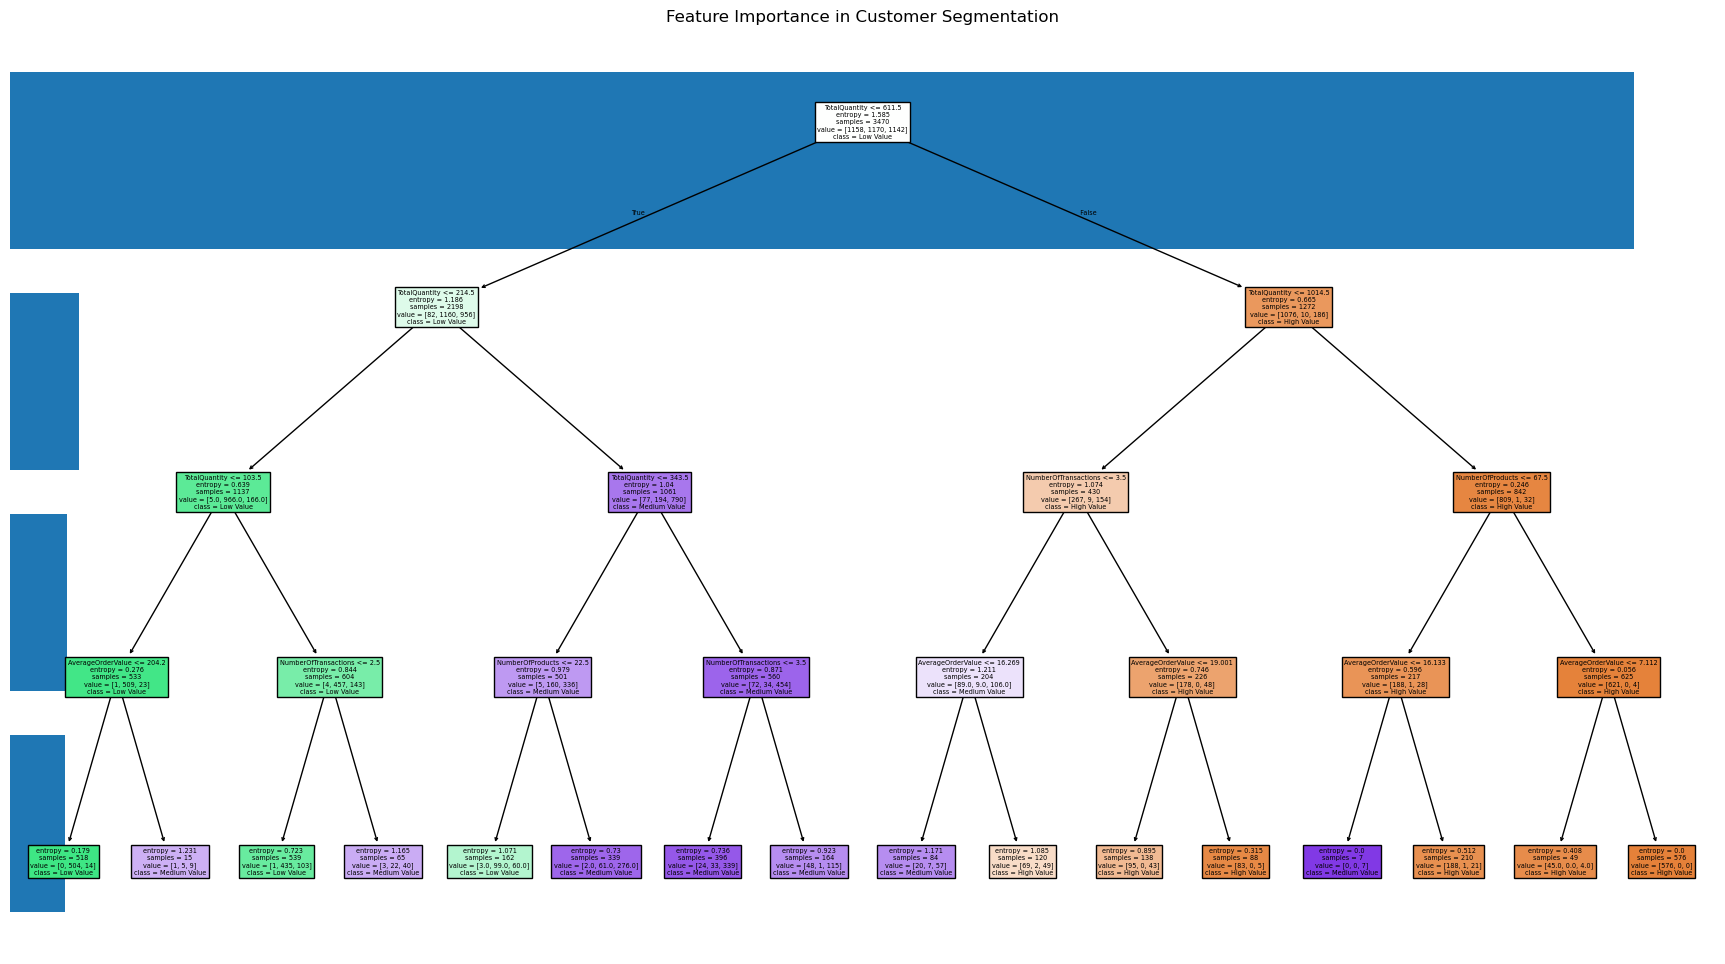

In [64]:
plt.figure(figsize = (22,12))

plot_tree(id3_model,
          feature_names =features,
          class_names=id3_model.classes_,
          filled=True,
          proportion = False
)
importance_sorted = importance.sort_values(
    "Importance",
    ascending = True
)
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["Importance"]
)
plt.xlabel("INformation-based importance")
plt.ylabel("Customer behavior Feature")
plt.title("Feature Importance in Customer Segmentation")

plt.show()
    
